<a href="https://colab.research.google.com/github/prof-atritiack/1CCPK-SERS-CP2-2SEM2026/blob/main/Aula_06_1CCPK_ML_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PREPARAÇÃO DO AMBIENTE

In [ ]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Separação de dados de treino e teste
from sklearn.model_selection import train_test_split

# Algoritmo escolhido para classificação binária: Logistic Regression
# Documentação: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

##CARGA DOS DADOS E CRIAÇÃO DO DATAFRAME

In [ ]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/1CCPK-SERS-CP2-2SEM2026/refs/heads/main/Data_for_UCI_named.csv')
dados.head(15)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [ ]:
y.shape

(10000,)

In [ ]:
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [ ]:
# Inspeção da coluna 'stabf'
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [ ]:
# Renomear as classes da coluna 'stabf'
dados['stabf'] = dados['stabf'].replace({'unstable': 'INSTÁVEL' , 'stable': 'ESTÁVEL' })
dados['stabf'].value_counts()

,count
stabf,
INSTÁVEL,6380
ESTÁVEL,3620


In [ ]:
# Target ----> Coluna 'stabf'
y = dados['stabf']
y

In [ ]:
# DataFrame X (Features ----> Dados de Entrada)
# Todos os atributos, exceto 'stab' e 'stabf'
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


# SEPARAÇÃO DE DADOS DE TREINO E TESTE

Critério: 75% para treino


In [ ]:
# train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [ ]:
# Número de registros do dataframe X
X.shape[0]

10000

In [ ]:
# Número de registros do set de treino (X_train)
X_train.shape[0]

7500

In [ ]:
# Número de registros do set de teste (X_test)
X_test.shape[0]

2500

##TREINAMENTO DO MODELO BASEADO EM REGRESSÃO LOGÍSTICA

In [ ]:
# Instanciando o modelo a partir da classe Logistic Regression do sklearn
grid_stability_model = LogisticRegression(random_state=1)

In [ ]:
# Treinamento
grid_stability_model.fit(X_train, y_train)

LogisticRegression(random_state=1)

In [ ]:
# Geração de previsões (y_predict ---> array com as previsões do modelo)
y_predict = grid_stability_model.predict(X_test)
y_predict

array(['INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', ..., 'ESTÁVEL', 'INSTÁVEL',
       'INSTÁVEL'], dtype=object)

In [ ]:
# Avaliação do modelo
print(f'Acurácia: {accuracy_score(y_test, y_predict):.3f}')
print(f'Precisão: {precision_score(y_test, y_predict, average='weighted'):.3f}')
print(f'Recall: {recall_score(y_test, y_predict, average='weighted'):.3f}')
print(f'F1 Score: {f1_score(y_test, y_predict, average='weighted'):.3f}')

Acurácia: 0.812
Precisão: 0.811
Recall: 0.812
F1 Score: 0.811


Observação: O parâmetro average='weighted' é usado para calcular as métricas de precisão, recall e F1-score de forma que a contribuição de cada classe (no seu caso, 'INSTÁVEL' e 'ESTÁVEL') seja ponderada pelo número de instâncias reais daquela classe na base de dados de teste. Isso é particularmente útil quando você tem um conjunto de dados desbalanceado (onde uma classe tem muito mais exemplos que a outra).

Em outras palavras, ele calcula a média das métricas por classe, mas dando mais 'peso' às classes que têm mais amostras.

Se você tivesse um conjunto de dados com 90% da classe A e 10% da classe B, e usasse average='weighted', a métrica final refletiria mais o desempenho na classe A, que é a classe majoritária, devido à sua maior proporção.

In [ ]:
# Criar a matriz de confusão com seaborn e matplot lib

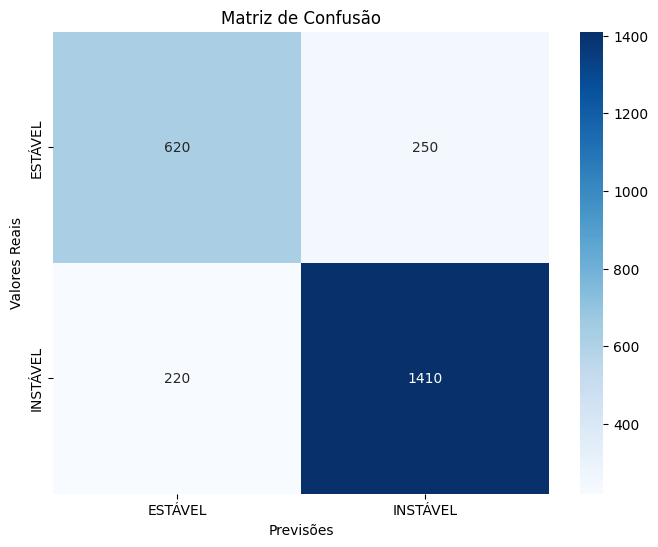

In [ ]:
cm = confusion_matrix(y_test, y_predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grid_stability_model.classes_,
            yticklabels=grid_stability_model.classes_)
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
# Classification report
cr = classification_report(y_test, y_predict)
print(cr)

              precision    recall  f1-score   support

     ESTÁVEL       0.74      0.71      0.73       870
    INSTÁVEL       0.85      0.87      0.86      1630

    accuracy                           0.81      2500
   macro avg       0.79      0.79      0.79      2500
weighted avg       0.81      0.81      0.81      2500



##EXERCÍCIO - AULA 07 - REGRESSÃO

Dataset escolhido: Individual Household Electric Power Consumption

Treinar um modelo preditivo de Regressão Linear para prever os dados do atributo Global_active_power com base nos demais atributos (encontrar os 3 com maior com maiores correlação linear). Criar um coluna com a somatória dos valores das colunas Sub_metering_1, Sub_metering_2 e Sub_metering_3.

Target (array y) ----> Global_active_power
Features (dataframe X) ----> 3 atributos com maior coeficiente de correlação linear comprovado com o Target (use matriz de correlação e gráficos de dispersão).
Gráficos: atr1 vs target, atr2 vs target, atr3 vs target

Entregar no final da atividade, as métricas --->
R2: Coeficiente de determinação
MAE: Erro médio absoluto
MSE: Erro médio quadrático
